# Benchmarking a selective query on 24 M Chicago taxi trips

**Blosc2 vs DuckDB, PyArrow, pandas, and polars — all querying straight from disk**

This notebook benchmarks one highly selective query against the flat
[Chicago Taxi](https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew)
dataset (~24.3 M trips, one row per trip), held in **two on-disk formats**
(**Parquet** and **Blosc2 `.b2z`**) and queried by **five** tools. Every tool
reads **from disk on demand** — nothing is pre-loaded into RAM.

The query (filter + projection + sort):

```sql
SELECT payment.tips, payment.total, trip.sec, trip.km, company
WHERE  payment.tips > 100 AND trip.km > 0 AND trip.begin.lon < 0
ORDER BY trip.sec
```

Only **67 of 24.3 M** rows match — exactly the regime where a format carrying
fine-grained, block-level indexes can win by *skipping* data instead of scanning it.

## The contenders

| Tool | Reads | What it is |
|------|-------|------------|
| **DuckDB** | Parquet | embedded analytical **SQL engine** — vectorized, multithreaded, with filter pushdown and late materialization |
| **PyArrow** | Parquet | columnar scanner with predicate / projection pushdown |
| **pandas** | Parquet | reads the columns into a DataFrame, then filters & sorts in NumPy |
| **polars** | Parquet | multithreaded streaming DataFrame engine |
| **Blosc2** | `.b2z` | a **pythonic, NumPy-native container** whose `where()` queries a compressed `CTable` via **block-level indexes** — no SQL engine in the loop |

The interesting question isn't "which dataframe library is fastest" — it's how a
plain, array-native **storage container** stacks up against a purpose-built
analytical engine like DuckDB on the engine's own turf. As we'll see, the answer
depends on whether the data is **cold on disk** (the realistic first-touch case,
where reading *less* wins) or already **warm in the OS cache** (where raw engine
throughput rules).

## Methodology

Each engine has its own small `select-*.py` script. Rather than time them in one
process (where warm caches and shared imports muddy the picture), the driver
`compare-query-methods.py` runs **each script in a fresh subprocess under
`/usr/bin/time`** (`-l` on macOS, `-v` on Linux). It captures three metrics:

* **script time** — wall-clock of the whole process; *dominated by interpreter +
  library import*, so not a pure engine comparison.
* **query time** — the `total:` line each script prints (open + compute + print),
  *excluding* import. **This is the fair engine-to-engine number.**
* **peak memory** — peak memory footprint (macOS) / max RSS (Linux).

We run it twice: once **cold** (`--nruns 1`, with the OS file cache flushed
right before — the driver's `--purge` flag automates this: `sudo purge` on
macOS, `drop_caches` on Linux, followed by a small read of the *other* input
file that wakes the disk, so the first timed read doesn't pay the device's
idle-state exit latency) and once **warm** (`--nruns 7`, best-of-7 with the
file fully cached). Best-of-N takes the minimum per metric — the run least
perturbed by background noise.


## Setup

In [1]:
import os
import subprocess
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display


def side_by_side(*paths, width=480):
    """Render several PNGs in a single horizontal row (self-contained base64)."""
    import base64

    imgs = "".join(
        f'<img src="data:image/png;base64,'
        f'{base64.b64encode(Path(p).read_bytes()).decode()}" '
        f'style="width:{width}px;max-width:49%;height:auto;margin:0 0.5%">'
        for p in paths
    )
    return HTML(
        f'<div style="display:flex;align-items:flex-start;flex-wrap:nowrap">{imgs}</div>'
    )

PARQUET = "chicago-taxi-flat.parquet"
B2Z = "chicago-taxi-flat.b2z"
URL = "https://cat2.cloud/demo/api/download/@public/large/" + PARQUET

print("platform:", sys.platform)
print("driver:   compare-query-methods.py")


platform: darwin
driver:   compare-query-methods.py


## 1. Get the dataset

If the parquet file isn't already in the working directory, download it
(~654 MB). We fetch to a temporary file and rename on success, so an interrupted
download never leaves a corrupt file that later steps would trust.


In [ ]:
if Path(PARQUET).exists():
    print(f"{PARQUET} already present ({Path(PARQUET).stat().st_size/1e6:.1f} MB) — skipping download")
else:
    tmp = PARQUET + ".tmp"
    print(f"downloading ~654 MB from {URL} ...")

    def _progress(block, bsize, total):
        done = block * bsize
        pct = f"{100*done/total:5.1f}%" if total > 0 else f"{done/1e6:.0f} MB"
        print(f"\r  {pct}  ({done/1e6:7.1f} MB)", end="")

    urllib.request.urlretrieve(URL, tmp, _progress)
    os.replace(tmp, PARQUET)
    print(f"\nsaved {PARQUET} ({Path(PARQUET).stat().st_size/1e6:.1f} MB)")


## 2. Build the Blosc2 `.b2z` store

Convert the parquet to a Blosc2 `CTable` once with the `parquet-to-blosc2` CLI.
(The driver would build it on first use too, but doing it explicitly here lets us
plot the storage sizes before benchmarking.)


In [3]:
if Path(B2Z).exists():
    print(f"{B2Z} already present — skipping build")
else:
    print(f"building {B2Z} from {PARQUET} ...")
    subprocess.run(["parquet-to-blosc2", PARQUET, B2Z, "--overwrite"], check=True)

parquet_mb = Path(PARQUET).stat().st_size / 1e6
b2z_mb = Path(B2Z).stat().st_size / 1e6
print(f"\n.parquet: {parquet_mb:7.1f} MB")
print(f".b2z:     {b2z_mb:7.1f} MB   ({b2z_mb/parquet_mb:.2f}x the parquet)")


chicago-taxi-flat.b2z already present — skipping build

.parquet:   654.0 MB
.b2z:       670.3 MB   (1.02x the parquet)


## 3. Storage footprint

The two on-disk formats are within a few percent. The `.b2z` is slightly larger
because it stores block-level indexes alongside the compressed data — the very
thing that lets it skip blocks during a selective query.


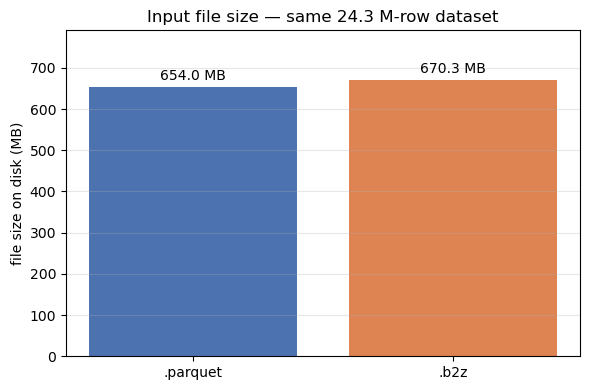

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([".parquet", ".b2z"], [parquet_mb, b2z_mb],
              color=["#4C72B0", "#DD8452"])
ax.bar_label(bars, fmt="%.1f MB", padding=3)
ax.set_ylabel("file size on disk (MB)")
ax.set_title("Input file size — same 24.3 M-row dataset")
ax.margins(y=0.18)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Cold run — `--nruns 1`

A single run with a cold OS file cache (closest to a one-shot, first-touch query).

**The cache must actually be cold.** The cell below runs the driver without
`--purge` so it works in any environment, which means *you* must flush the OS
file cache right before executing it: `sudo purge` on macOS, or
`sync && echo 3 | sudo tee /proc/sys/vm/drop_caches` on Linux. Alternatively,
run the driver from a terminal with `sudo -v && python compare-query-methods.py
--nruns 1 --purge`, which flushes before every run automatically.

One subtlety worth knowing: after a flush plus a few idle seconds, the first
disk read can pay the storage device's idle-state exit latency (tens of ms on
NVMe drives with power management), which lands on whichever process touches
the disk first — not on the engine being measured. `--purge` handles this by
waking the disk with a small read of the *other* input file after each flush;
if flushing manually, touch the disk once (e.g. `head -c 4000000
chicago-taxi-flat.parquet > /dev/null`) right before running the cell.

The driver prints a per-run line, a cross-method **row-count check** (all engines
must return the same 67 rows, else they aren't computing the same query), and a
summary table, then writes the `*-cold.png` plots.


In [5]:
cold = subprocess.run([sys.executable, "compare-query-methods.py", "--nruns", "1"],
                      capture_output=True, text=True)
print(cold.stdout)
if cold.returncode != 0:
    print(cold.stderr)


== duckdb  (select-duckdb-flat.py chicago-taxi-flat.parquet, 654.0 MB) ==
   run 1/1: script  0.200 s  query  0.107 s      59.8 MB
== arrow   (select-arrow-flat.py chicago-taxi-flat.parquet, 654.0 MB) ==
   run 1/1: script  0.550 s  query  0.137 s     226.0 MB
== pandas  (select-pandas-flat.py chicago-taxi-flat.parquet, 654.0 MB) ==
   run 1/1: script  0.780 s  query  0.534 s    1570.9 MB
== polars  (select-polars-flat.py chicago-taxi-flat.parquet, 654.0 MB) ==
   run 1/1: script  0.540 s  query  0.298 s     404.5 MB
== blosc2  (select-blosc2.py chicago-taxi-flat.b2z, 670.3 MB) ==
   run 1/1: script  0.180 s  query  0.056 s      83.3 MB

row-count check OK: all methods returned 67 rows

method    script (s)   query (s)   peak mem (MB)   size (MB)    rows
--------------------------------------------------------------------
duckdb         0.200       0.107            59.8       654.0      67
arrow          0.550       0.137           226.0       654.0      67
pandas         0.780       0


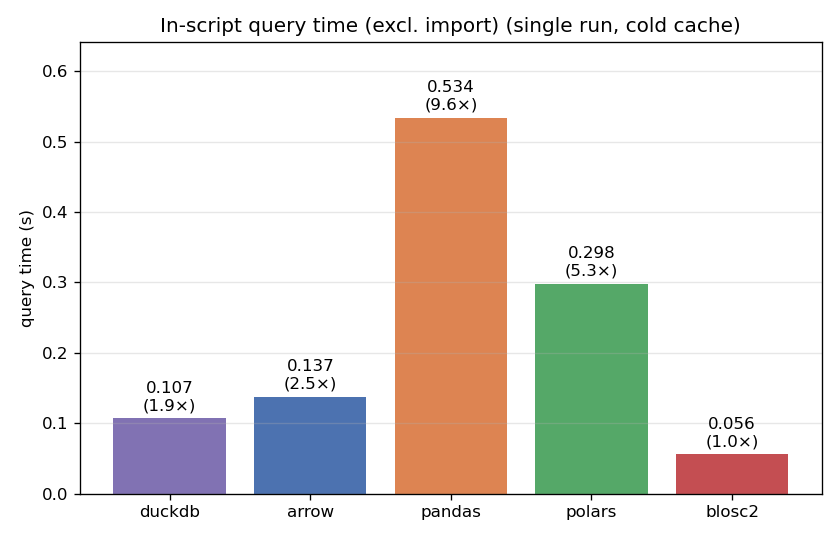
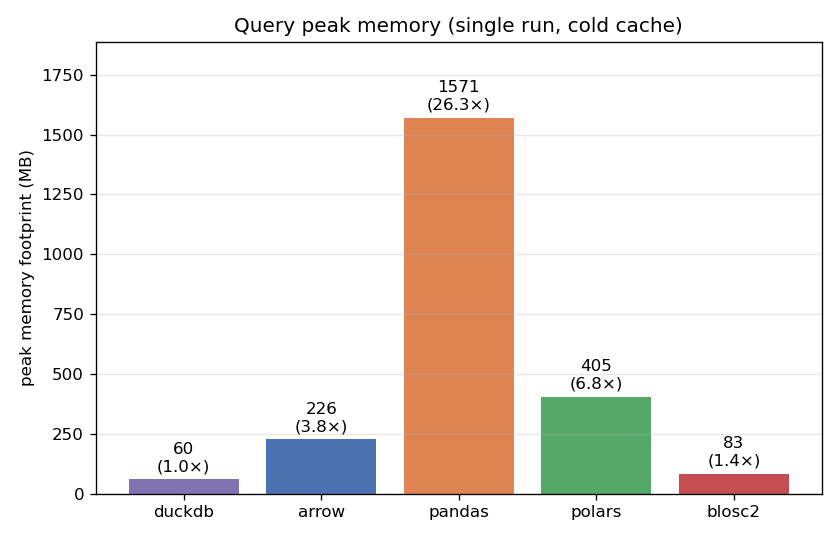

In [6]:
side_by_side("compare-query-time-cold.png", "compare-query-mem-cold.png")

## 5. Warm run — `--nruns 7` (best of 7)

Seven runs per engine with a warm cache; the driver keeps the minimum per metric
and draws min→max error bars so you can see how stable each measurement is. This
is the steady-state comparison.


In [7]:
warm = subprocess.run([sys.executable, "compare-query-methods.py", "--nruns", "7"],
                      capture_output=True, text=True)
print(warm.stdout)
if warm.returncode != 0:
    print(warm.stderr)


== duckdb  (select-duckdb-flat.py chicago-taxi-flat.parquet, 654.0 MB) ==
   run 1/7: script  0.080 s  query  0.035 s      60.9 MB
   run 2/7: script  0.080 s  query  0.034 s      62.1 MB
   run 3/7: script  0.080 s  query  0.036 s      61.3 MB
   run 4/7: script  0.070 s  query  0.034 s      61.7 MB
   run 5/7: script  0.080 s  query  0.035 s      60.5 MB
   run 6/7: script  0.080 s  query  0.035 s      62.2 MB
   run 7/7: script  0.080 s  query  0.035 s      61.3 MB
== arrow   (select-arrow-flat.py chicago-taxi-flat.parquet, 654.0 MB) ==
   run 1/7: script  0.340 s  query  0.087 s     232.9 MB
   run 2/7: script  0.340 s  query  0.089 s     209.3 MB
   run 3/7: script  0.350 s  query  0.087 s     236.0 MB
   run 4/7: script  0.350 s  query  0.089 s     222.4 MB
   run 5/7: script  0.340 s  query  0.089 s     239.3 MB
   run 6/7: script  0.340 s  query  0.087 s     223.6 MB
   run 7/7: script  0.350 s  query  0.089 s     218.3 MB
== pandas  (select-pandas-flat.py chicago-taxi-flat.par


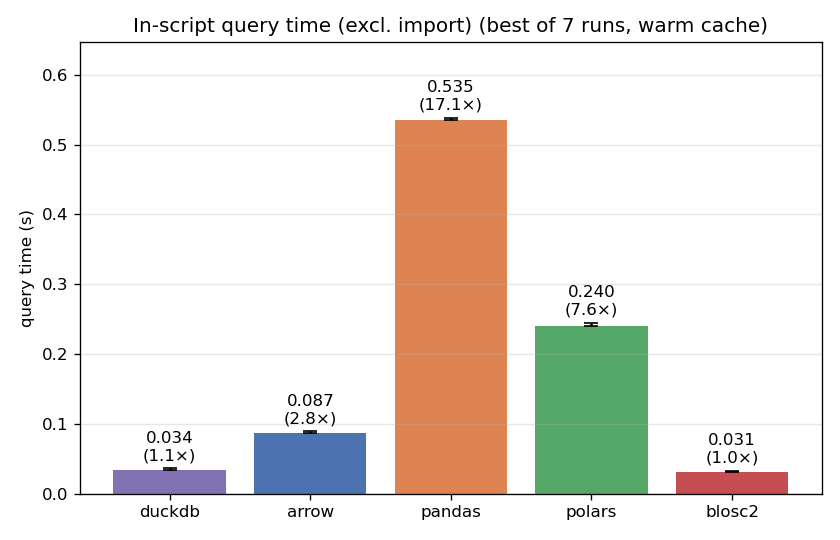
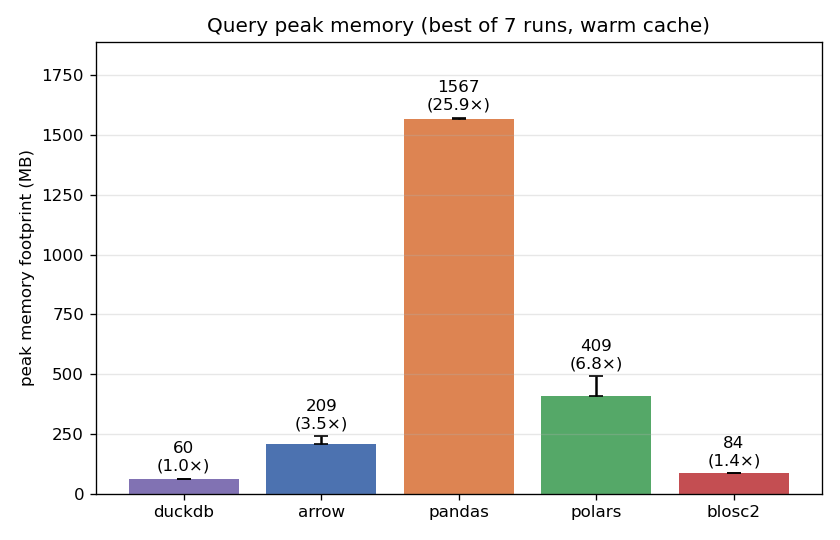

In [8]:
side_by_side("compare-query-time-warm.png", "compare-query-mem-warm.png")

## Observations

*(Numbers below are representative of the executed summary tables and plots above —
re-running the notebook refreshes them; exact figures vary a little by machine and
cache state.)*

### Script time vs query time
The **script time** bars are dominated by Python interpreter startup plus library
import — ~0.1 s for DuckDB up to ~0.8 s for pandas, all spent *before any data is
touched*. That overhead is real for a one-shot CLI invocation, but it isn't the
engine. The honest engine-to-engine comparison is the **query time** (each
script's own `total:`), which strips import out. Read the `-time` plots.

### Cold cache — the realistic first-touch query (`--nruns 1`, after `purge`)
This is the case that matters most in practice: you open a file that *isn't*
already in RAM and run the query once. Here the data must actually be read from
disk, and **reading less wins**:

- **Blosc2 is the fastest, outright** (~0.06 s) — about **1.7× faster than DuckDB**
  (~0.10 s), **2.3× faster than arrow** (~0.14 s), **5× faster than polars**
  (~0.33 s) and **9× faster than pandas** (~0.55 s).
- It wins because its **block-level indexes let it skip ~89 % of the file** (see
  below). When bytes have to come off cold disk, touching one-tenth of them is the
  whole ballgame — pruning pays *twice*: less to read **and** less to decompress.

### Warm cache — steady state (`--nruns 7`, best of 7)
Once the file is fully cached in RAM, I/O is essentially free and the picture
changes: raw engine throughput catches up.

- **DuckDB** (~0.034 s) and **Blosc2** (~0.036 s) finish in a **dead heat** for
  fastest — both still ~2.5× faster than arrow, ~7× faster than polars and ~15×
  faster than pandas.
- DuckDB closes the cold-cache gap here through its vectorized, multithreaded core
  and late materialization; Blosc2 holds the tie purely by decompressing the few
  blocks it can't prune.

The headline across both regimes: a plain **NumPy-native container is fastest when
it counts (cold) and ties a purpose-built analytical database when warm** — with
no SQL engine in the process.

### Arrays out, not a result set
The query result is itself a **NumPy-addressable view**: slicing a column realizes
it to a plain `ndarray` with its original dtype, materializing only the matching
rows — no `.to_numpy()` hop, no DataFrame/Arrow/SQL intermediary.

```python
import blosc2
t = blosc2.open("chicago-taxi-flat.b2z")
v = t.where((t.payment.tips > 100) & (t.trip.km > 0) & (t.trip.sec > 0))
v.trip.sec[:]          # -> np.ndarray, dtype=float32, just the 67 matching values
```

The dataframe tools reach NumPy only via an explicit `.to_numpy()` (zero-copy at
best, a copy with nulls / non-numeric columns); DuckDB returns a SQL result set
you then materialize. Blosc2 hands you arrays directly.

### Why pruning wins — block vs row-group granularity
Blosc2's edge comes from *skipping work*, and the lever is **granularity**:

- **Blosc2** builds its SUMMARY index at **block** granularity (here ~27 K
  rows/block), so it decompresses only the blocks that can satisfy the filter.
- **Parquet** keeps min/max stats at **row-group** granularity (here ~970 K
  rows/group) — roughly **36× coarser**. Every one of Parquet's row groups
  contains *some* `payment.tips > 100`, so a min/max layer over them prunes
  **0 row groups**; everyone reading Parquet (DuckDB, arrow, polars, pandas) must
  stream far more of the file.

| | summary unit | rows/unit | pruned on this query |
|---|---|---:|---|
| Parquet row-group stats | row group | ~970,000 | 0 of 25 (0 %) |
| Blosc2 SUMMARY index | **block** | **~27,000** | **~809 of 906 (~89 %)** |

A Blosc2 **block is the unit of decompression**, so a block-level summary lets the
engine skip a block's *read and decompression entirely* — the index granularity is
aligned with the work it avoids. That's why the advantage is largest on a **cold**
cache, where avoided reads are avoided disk I/O, and shrinks to a tie once
everything is in RAM and only CPU throughput separates the engines.

Caveat: this win rides on **selectivity**, not sorting. It works because
`tips > 100` is rare enough that ~89 % of 27 K-row blocks contain no match. A
non-selective predicate prunes nothing at any granularity, and heavily
sorted/clustered data would let even Parquet's coarse row groups start pruning.

### Memory
- **pandas** peaks the highest (well over 1 GB): it **materializes the full
  columns** into a DataFrame before filtering, so the working set is the whole
  projection, not the 67 matching rows.
- **DuckDB** (~60 MB) and **Blosc2** (~85 MB) are the two leanest by a wide margin —
  an **order of magnitude** below pandas, in both cold and warm runs. DuckDB
  streams with late materialization; Blosc2 never loads the whole file, only the
  handful of blocks it cannot prune.
- arrow (~220–275 MB) and polars (~415–460 MB) land in between.

### Storage
- `.b2z` is a few percent larger than `.parquet` here (see the size plot). Those
  extra bytes are the block indexes that enable the pruning above — and the file
  **stays compressed on disk**, just like Parquet.


## Take-away

> **For a selective first-touch query against on-disk data, Blosc2 `.b2z` is the
> fastest of all five tools — and it ties a purpose-built SQL engine even once the
> file is warm in RAM — while staying a simple, NumPy-native Python container.**
>
> On a **cold cache** (the realistic one-shot case), Blosc2 was **~1.7× faster
> than DuckDB and 2–9× faster than the dataframe tools**, because its block-level
> indexes read and decompress only ~11 % of the file. On a **warm cache** it
> **tied DuckDB for fastest** and stayed among the leanest on memory (an order of
> magnitude below pandas). All of this sits behind a plain `where()` that returns
> arrays. The price is a **small on-disk penalty** versus Parquet (a few percent).

| Aspect | pandas / polars / arrow | DuckDB | Blosc2 `.b2z` |
|--------|:-----------------------:|:------:|:-------------:|
| Query time — cold cache (first touch) | slower | 2nd | ✅ **fastest** |
| Query time — warm cache (steady state) | slower | ✅ fastest | ✅ fastest (tied) |
| Peak memory | higher | ✅ lowest | ✅ near-lowest |
| On-disk size | ✅ smallest (parquet) | ✅ smallest (parquet) | small penalty |
| Stays compressed on disk | ✅ | ✅ | ✅ |
| Native NumPy arrays (no conversion step) | partial (`.to_numpy()`) | ✗ (SQL result set) | ✅ ([:] → `ndarray`, dtype kept) |

## Blosc2 — a well-balanced, pythonic container for persistent tabular data

DuckDB is excellent, and these numbers show it. But it's an embedded *analytical
database*: you speak SQL to it and it hands you a result set. Blosc2 answers a
different need — **persistent tabular data that lives in a simple, compressed,
array-native container** any Python code can open and read.

What makes Blosc2 a great alternative to Parquet as a *format*:

- **Pythonic and NumPy-native.** A `CTable` is columns of arrays. `where()` takes a
  Python expression and returns arrays — no query engine to stand up, no SQL, no
  DataFrame conversion tax. It composes naturally with NumPy, and the data is
  ready for compute the moment it's read.
- **Block-level indexing built in.** The same indexes that cost a few percent of
  disk make it the **fastest tool here on a cold cache** and tie the best engine
  when warm — pruning that Parquet's coarser row-group stats can't match — plus
  the lowest memory among the dataframe tools.
- **Stays compressed end-to-end.** Like Parquet, the data is compressed on disk;
  unlike a query engine, you keep direct, array-level access to it.
- **Well-balanced.** It trades a few percent of disk space for the best
  first-touch query speed, an order-of-magnitude memory win over the dataframe
  tools, and a container that's a pleasure to use from plain Python.

### Beyond this benchmark

This query is a narrow slice of what the container does. Three capabilities — not
exercised above, but central to why Blosc2 fits the NumPy/pandas crowd — are worth
naming (described here as features, not benchmarked):

- **Native N-dimensional arrays — even as table columns.** Blosc2 is an array
  library at heart: `NDArray` is a first-class compressed n-dim array, and a
  `CTable` column can itself be multidimensional. Store an image, spectrum, or
  embedding *per row* next to scalar fields — compressed and NumPy-addressable —
  something the tabular engines can't express and Arrow only approximates with a
  young, compute-less tensor extension type.
- **Out-of-core compute with NumPy/array semantics.** Lazy expressions like
  `(t.a + t.b * 2)` evaluate block-by-block on compressed, possibly
  larger-than-RAM data and return arrays. Arrow/polars/DuckDB also stream
  out-of-core, but through a *relational* API (scan/filter/join/aggregate);
  Blosc2 streams *array* math — and over n-dim arrays, which the tabular engines
  have no way to express.
- **Native NumPy integration and array-standard alignment.** Data goes in and
  comes out as plain `ndarray`s, and Blosc2 tracks the
  [Python Array API standard](https://data-apis.org) — so it behaves like the
  array/dataframe objects the NumPy/pandas/Python ecosystem already expects,
  rather than a foreign result set you must convert.

If you reach for Parquet to keep tabular data on disk but want it to behave like a
fast, compressed, array-native Python object — not a file you must hand to an
engine — Blosc2 `.b2z` is the well-balanced alternative.
